# Revealing the Domains of Scene Evaluation from Natural Language

This project aims to understand which domains people spontaneously rely on when visually perceiving outdoor scenes, addressing a gap in prior research that has focused mainly on predefined categories in scene perception/categorization.

This data analysis pipeline aims to analyze the language participants use in written free responses in order to understand the underlying structure of scene perception.

In [441]:
# Magic commands
%reset -f
%matplotlib inline
# %matplotlib widget
# %matplotlib nbagg
# use osx or widget instead of inline on mac — pip install ipympl to allow widget to work
%config InlineBackend.figure_format = "retina" # High-res graphs (rendered irrelevant by svg option below)
%config InlineBackend.print_figure_kwargs = {"bbox_inches": "tight"} # No extra white space
%config InlineBackend.figure_format = "svg" # png is default

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # a helpful package for making plots
import sys
from pathlib import Path

##### Extra Imports

# data cleaning
import ast
import string
import re

# word frequency
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud, STOPWORDS

# word co-occurrence
from collections import defaultdict
from itertools import combinations


# topic modeling (LDA)
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

#SBERT

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

## 0. Load Data

The following code loads and checks the raw data (.csv). 

The BCOG200 project uses the example dataset "main_data.csv", which is the text response collected from participants who viewed images of cars. Later, the example dataset will be replaced with the actual data collected for the scene evaluation project. 

In [442]:
#load_data function
def load_data(file_name):
    data_path = Path("data") / file_name
    data = pd.read_csv(data_path)
    return data

In [443]:
#load "main_data.csv"
raw_data = load_data("main_data.csv")

#check
raw_data.head()

,rt,url,experiment_phase,refresh_count,trial_type,trial_index,time_elapsed,experiment_name,assignment_id,hit_id,...,window_width,window_height,form_name,form_id,instructions_viewed_count,view_history,responses,stimulus,form_data,is_prolific
0,39511.6,NaN,main,0,face-description-trial,4,84918,car_description_survey_2023-05-14,3IGI0VL64E0GWXBBNF2YI1R1DLHNO8,372AGES0JALLIKK2RB1ALEREDS7XRN,...,NaN,NaN,NaN,NaN,NaN,NaN,{'Q0': 'a blue car just sitting in an empty pa...,https://tlab-objects.s3.us-east-2.amazonaws.co...,NaN,False
1,27368.1,NaN,main,0,face-description-trial,5,112393,car_description_survey_2023-05-14,3IGI0VL64E0GWXBBNF2YI1R1DLHNO8,372AGES0JALLIKK2RB1ALEREDS7XRN,...,NaN,NaN,NaN,NaN,NaN,NaN,{'Q0': 'a white car in a parking lot it might ...,https://tlab-objects.s3.us-east-2.amazonaws.co...,NaN,False
2,29392.1,NaN,main,0,face-description-trial,6,141895,car_description_survey_2023-05-14,3IGI0VL64E0GWXBBNF2YI1R1DLHNO8,372AGES0JALLIKK2RB1ALEREDS7XRN,...,NaN,NaN,NaN,NaN,NaN,NaN,{'Q0': 'a gray possibly sitting in a driveway ...,https://tlab-objects.s3.us-east-2.amazonaws.co...,NaN,False
3,18590.4,NaN,main,0,face-description-trial,7,160595,car_description_survey_2023-05-14,3IGI0VL64E0GWXBBNF2YI1R1DLHNO8,372AGES0JALLIKK2RB1ALEREDS7XRN,...,NaN,NaN,NaN,NaN,NaN,NaN,{'Q0': 'a blue sedan in a parking lot with tre...,https://tlab-objects.s3.us-east-2.amazonaws.co...,NaN,False
4,24727.6,NaN,main,0,face-description-trial,8,185433,car_description_survey_2023-05-14,3IGI0VL64E0GWXBBNF2YI1R1DLHNO8,372AGES0JALLIKK2RB1ALEREDS7XRN,...,NaN,NaN,NaN,NaN,NaN,NaN,{'Q0': 'a red car that is more of an older mod...,https://tlab-objects.s3.us-east-2.amazonaws.co...,NaN,False


As seen above, the text responses will be recorded under a column named "responses." This column will be made into a variable named "response_col."

In [444]:
response_col = raw_data.responses

#check
response_col

0       {'Q0': 'a blue car just sitting in an empty pa...
1       {'Q0': 'a white car in a parking lot it might ...
2       {'Q0': 'a gray possibly sitting in a driveway ...
3       {'Q0': 'a blue sedan in a parking lot with tre...
4       {'Q0': 'a red car that is more of an older mod...
                              ...                        
1095    {'Q0': 'I worry about small cars like this. I ...
1096    {'Q0': 'It seems exciting because of the red c...
1097    {'Q0': "It seems like an older model, somethin...
1098    {'Q0': "I really like this car, and not just b...
1099    {'Q0': 'This car is way too boxy. I feel like ...
Name: responses, Length: 1100, dtype: str

## 1. Preprocess Responses

Preprocessing will include changing the data into an easily manipulable format and data cleaning. 

### Data Formatting

Participant responses will initially be recorded in strings. To make the content easier to manipulate, each string will be converted into a dictionary object. The following function does this; also, its try & except block filters out values that cannot be safely parsed into valid Python dictionary objects (e.g., responses not in the expected format).

In [445]:
def string_to_dict(responses):
    try:
        return ast.literal_eval(responses)
    except (ValueError, SyntaxError):
        return {}

response_col_dic = response_col.apply(string_to_dict)
response_col_dic.head()

0    {'Q0': 'a blue car just sitting in an empty pa...
1    {'Q0': 'a white car in a parking lot it might ...
2    {'Q0': 'a gray possibly sitting in a driveway ...
3    {'Q0': 'a blue sedan in a parking lot with tre...
4    {'Q0': 'a red car that is more of an older mod...
Name: responses, dtype: object

The responses will be extracted from the dictionary created above for the cleaning procedures.

In the example dataset, the plain text response is stored under the key "Q0". The function below retrieves the value associated with this key, returning an empty string if the key is missing.

In [446]:
def extract_text(dictionary):
    return dictionary.get("Q0", "")

response_text = response_col_dic.apply(extract_text)
response_text.head()

0    a blue car just sitting in an empty parking lo...
1    a white car in a parking lot it might just be ...
2    a gray possibly sitting in a driveway , it mig...
3    a blue sedan in a parking lot with trees behin...
4    a red car that is more of an older model that ...
Name: responses, dtype: str

### Identifying & Removing Invalid Values

First, the data will be checked for any missing values.

In [447]:
"Missing values:", response_text.isna().any()

('Missing values:', np.False_)

The example dataset returns "False," indicating that no NaN value was detected in the response column.

If the output were "True," the very line with the NaN value will be checked and treated.

Before proceeding to data cleaning, the recorded responses will be manually read to identify any abnormal or invalid entries.

Since some responses in the example dataset contained hyperlinks to specific stimuli (e.g., https://tlab-objects.s3.us-east-2.amazonaws.com/cars/images/description/0023.png), the corresponding rows will be detected and removed.

In [448]:
# check how many responses contain "http"
http_rows = response_text.str.contains(
    "http",
    case=False,
    na=False
)

# number of rows with "http"
http_rows.sum() 

np.int64(12)

In [449]:
# The output says there are 12 rows with "http." 
# The following code removes them.

response_text = response_text[
    ~http_rows
]

# reset index
response_text = response_text.reset_index(drop=True)

# check
response_text.head()

0    a blue car just sitting in an empty parking lo...
1    a white car in a parking lot it might just be ...
2    a gray possibly sitting in a driveway , it mig...
3    a blue sedan in a parking lot with trees behin...
4    a red car that is more of an older model that ...
Name: responses, dtype: str

In the actual dataset, other methods will also be applied to identify and remove invalid responses. 

Data from participants who wrote nonsensical responses or who took an unusually short or long time completing the experiment will be removed. 

### Data Cleaning

The following functions perform text cleaning procedures: stripping whitespace, lowercasing, and removing punctuation.

In [450]:
# 1. strip whitespace
def strip_text(response):
    return response.strip()

# 2. Lowercase
def lowercase_text(response):
    return response.lower()

# 3. Remove punctuation
# This function removes all punctuations except - (hyphen).
def remove_punctuation(response):
    punctuation_without_hyphen = string.punctuation.replace("-", "")

    return response.translate(
        str.maketrans("", "", punctuation_without_hyphen)
    )

The following code applies each function and shows the preview. 

In [451]:
# 1. strip whitespace
response_col_clean1 = response_text.apply(strip_text)
response_col_clean1.head()

0    a blue car just sitting in an empty parking lo...
1    a white car in a parking lot it might just be ...
2    a gray possibly sitting in a driveway , it mig...
3    a blue sedan in a parking lot with trees behin...
4    a red car that is more of an older model that ...
Name: responses, dtype: str

In [452]:
# 2. Lowercase
response_col_clean2 = response_col_clean1.apply(lowercase_text)
response_col_clean2.head()

0    a blue car just sitting in an empty parking lo...
1    a white car in a parking lot it might just be ...
2    a gray possibly sitting in a driveway , it mig...
3    a blue sedan in a parking lot with trees behin...
4    a red car that is more of an older model that ...
Name: responses, dtype: str

In [453]:
# 3. Remove punctuation
response_col_clean3 = response_col_clean2.apply(remove_punctuation)
response_col_clean3.head()

0    a blue car just sitting in an empty parking lo...
1    a white car in a parking lot it might just be ...
2    a gray possibly sitting in a driveway  it migh...
3    a blue sedan in a parking lot with trees behin...
4    a red car that is more of an older model that ...
Name: responses, dtype: str

For punctuation removal, words with hyphens will be inspected separately, as hyphenated expressions may carry meaningful information. 

The following function detects words with hyphens.

In [454]:
def find_hyphen_words(text_column):

    hyphen_words = set()
    for text in text_column:
        matches = re.findall(r"\b\w+(?:-\w+)+\b", str(text))

        hyphen_words.update(matches)

    return sorted(hyphen_words)

In [455]:
hyphen_words = find_hyphen_words(response_col_clean3)

#check
hyphen_words

['2-door',
 '4-door',
 '60-70s',
 '70-80s',
 'beat-up',
 'black-ish',
 'blackish-blue',
 'blue-grey',
 'bluish-gray',
 'box-like',
 'box-shaped',
 'box-type',
 'classic-looking',
 'cream-colored',
 'cross-over',
 'cul-de-sac',
 'fancy-looking',
 'four-door',
 'four-dour',
 'gray-colored',
 'great-looking',
 'green-ish',
 'grey-black',
 'lot-class',
 'low-riding',
 'low-slung',
 'mid-90s',
 'mid-sized',
 'middle-class',
 'mini-suv',
 'mis-matched',
 'multi-tone',
 'nice-looking',
 'non-conspicious',
 'non-conspicous',
 'non-descript',
 'normal-looking',
 'odd-looking',
 'off-white',
 'old-looking',
 'old-persons',
 'orange-red',
 'outdoorsy-type',
 'passenger-side',
 'pick-up',
 'pop-up',
 'reddish-brown',
 'run-of-the-mill',
 'semi-compact',
 'semi-rural',
 'sporty-looking',
 'street-racer',
 'sun-drenched',
 'trans-am',
 'tree-lined',
 'truck-like',
 'two-door',
 'war-torn',
 'well-maintained',
 'yellow-orange']

Hyphenated words will be manually inspected and retained as single words when they do not pose issues.

The cleaned data will be saved as a new .csv file named "main_clean.csv" in /data.

In [456]:
data_output_path = Path("data/main_clean.csv")
response_col_clean3.to_csv(data_output_path, index=False)

## 2. Exploratory Analysis

This project aims to build a dictionary of domains. As no predefined dictionary exists for scene perception (unlike in the previous face impression study, Nicholas et al., 2025), the responses will be examined to identify some candidate domains.

But before doing that, this pipeline will inspect the text data by calculating word frequency, creating a list of stopwords and removing them, and computing word co-occurrence. 

But first, the cleaned dataset will be loaded and checked by calculating the number of responses. 

In [457]:
#load "clean_data.csv"
clean_data = load_data("main_clean.csv")

#check
clean_data.head()

,responses
0,a blue car just sitting in an empty parking lo...
1,a white car in a parking lot it might just be ...
2,a gray possibly sitting in a driveway it migh...
3,a blue sedan in a parking lot with trees behin...
4,a red car that is more of an older model that ...


In [458]:
# check; calculate the number of responses (= rows)
"Number of responses/rows:", len(clean_data), "rows"

('Number of responses/rows:', 1088, 'rows')

### Calculate Word Frequency

The word frequency will be calculated to see which words appear most often across participant responses.

In [466]:
def get_word_frequency(some_text):
    all_tokens = []

    for text in some_text:
        tokens = text.split()
        all_tokens.extend(tokens)

    word_counts = Counter(all_tokens)

    freq_df = pd.DataFrame(word_counts.items(), columns=["word", "count"])
    freq_df = freq_df.sort_values("count", ascending=False).reset_index(drop=True)

    return freq_df

In [467]:
frequency_df = get_word_frequency(clean_data["responses"])

#check
frequency_df.head(50)

,word,count
0,a,1326
1,car,1037
2,the,953
3,is,765
4,it,703
5,and,620
6,in,502
7,looks,455
8,this,430
9,of,422


### Remove Stopwords

The list below contains repeated stopwords and introductory phrases (e.g., “it is,” “it looks,” and “I think”) that primarily are part of sentence structure rather than meaningful evaluative content. 

The phrases to remove were selected, referring to Nicolas et al. (2025). For reference, phrases removed in Nicolas et al. (2025): he is |he has |she is |she has|she looks |he looks |i think

The stopwords are selected from WordCloud's Stopwords by ChatGPT. 

In [468]:
from wordcloud import STOPWORDS

wc_stopwords = sorted(list(STOPWORDS))

print("WordCloud stopwords:")
print(wc_stopwords)   # first 50
print("total:", len(wc_stopwords))

WordCloud stopwords:
['a', 'about', 'above', 'after', 'again', 'against', 'all', 'also', 'am', 'an', 'and', 'any', 'are', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', "can't", 'cannot', 'com', 'could', "couldn't", 'did', "didn't", 'do', 'does', "doesn't", 'doing', "don't", 'down', 'during', 'each', 'else', 'ever', 'few', 'for', 'from', 'further', 'get', 'had', "hadn't", 'has', "hasn't", 'have', "haven't", 'having', 'he', "he'd", "he'll", "he's", 'hence', 'her', 'here', "here's", 'hers', 'herself', 'him', 'himself', 'his', 'how', "how's", 'however', 'http', 'i', "i'd", "i'll", "i'm", "i've", 'if', 'in', 'into', 'is', "isn't", 'it', "it's", 'its', 'itself', 'just', 'k', "let's", 'like', 'me', 'more', 'most', "mustn't", 'my', 'myself', 'no', 'nor', 'not', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'otherwise', 'ought', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 'r', 'same', 'shall', "shan't", 'she', "she'd"

In [472]:
stopword_list = [
    #phrases
    "it",
    "its",
    "it is ",
    "its ",
    "it has ",
    "it looks ",
    "i think ",
    "i feel ",
    "this is ",
    "there is ",
    "there are ",
    "looks like ",
    "seems like ",

    #conjugations and prepositions from WordCloud's Stopwords
    
    # AI attribution: Used ChatGPT (accessed 2026-05-11) to filter conjugations and prepositions from 192 stopwords provided by WordCloud
    # Prompt: "Pull out conjugations and prepositions from this list and make a Python list [code snippet]"
    # I read through the generated list and added missing words (e.g., a, i), and copy-pasted it inside my "stopword_list."

    "and",
    "as",
    "at",
    "because",
    "before",
    "between",
    "but",
    "by",
    "during",
    "for",
    "from",
    "if",
    "in",
    "into",
    "of",
    "off",
    "on",
    "or",
    "out",
    "over",
    "since",
    "so",
    "than",
    "through",
    "to",
    "under",
    "until",
    "up",
    "while",
    "with",

    # added
    "a",
    "i",
    "an",
    "the",
    "is",
    "are",
    "was",
    "were",
    "be",  
    "am",
    "this",
    "that"
]

Along with the phrases above, neutral words that are without a meaningful meaning (e.g., "car" in the example dataset) will also be removed.

The following function removes a predefined list of phrases & neutral words from the text response.

In [473]:
# set a neutral word list
neutral_word_list = ["car", "cars"]

#for the scenes, the possible neutral words could be: 
#neutral_word_list = ["scene", "environment"]

def remove_words(df, word_list1, word_list2):
    all_words = word_list1 + word_list2

    #word frequency df
    if "word" in df.columns:
        filtered_df = df[~df["word"].isin(all_words)]
        
    # filtered_df = df[~df["word"].isin(all_words)].reset_index(drop=True)

    #word co-occurrence df 
    elif "word_1" in df.columns and "word_2" in df.columns:
        filtered_df = df[
            ~df["word_1"].isin(all_words) & ~df["word_2"].isin(all_words)
        ]

    else:
        raise ValueError("df's format is unknown. May have to edit def remove_words!")
    
    return filtered_df

In [474]:
filtered_frequency_df = remove_words(
    frequency_df,
    stopword_list,
    neutral_word_list
)
filtered_frequency_df.head(50)

,word,count
7,looks,455
10,like,405
15,very,226
17,parked,189
19,color,181
20,sedan,180
22,has,173
23,blue,168
26,older,163
27,old,157


### Data Visualization

A bar graph and a word cloud will be used to visualize the ranked frequency of words.

In [475]:
def plot_bargraph(
    df,
    x_col,
    y_col,
    top_n=20,
    xlabel="",
    ylabel="Frequency",
    title=""
):

    # select top rows
    top_df = df.head(top_n)

    plt.figure(figsize=(10, 5))

    plt.bar(
        top_df[x_col],
        top_df[y_col],
        edgecolor="black"
    )

    plt.xticks(rotation=60, ha="right")

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    plt.tight_layout()
    plt.show()

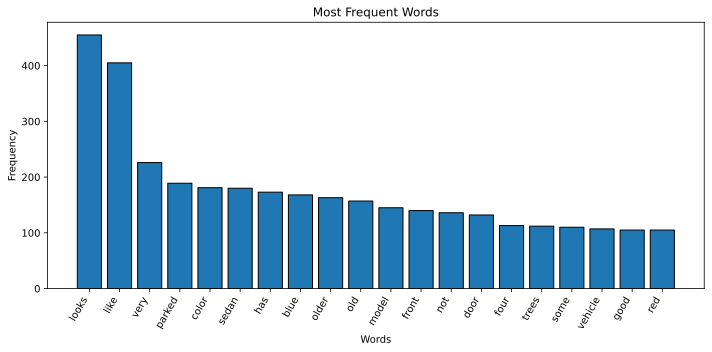

In [476]:
# draw a bar graph
plot_bargraph(
    df=filtered_frequency_df,
    x_col="word",
    y_col="count",
    top_n=20,
    xlabel="Words",
    ylabel="Frequency",
    title="Most Frequent Words"
)

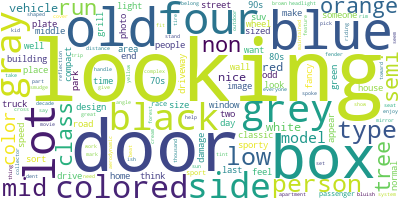

In [477]:
# draw a word cloud

long_string = ','.join(list(filtered_frequency_df['word'].values))

wordcloud = WordCloud(background_color="white", max_words=5000, contour_width=3, contour_color='steelblue')

wordcloud.generate(long_string)

wordcloud.to_image()

### Compute Word Co-occurence

This step will examine which words tend to appear together in participant responses.

Co-occurring words may reflect a shared conceptual domain. (e.g., Words such as "quite" and "peaceful" may co-occur in higher frequency than "quiet" and "angry.")

The following function calculates word co-occurrence frequencies across responses. After tokenizing each response into words, duplicate words within a response are removed. Then, all possible word pairs are generated, and their frequencies are counted. Calculated frequencies are stored in a dataframe. 

In [478]:
def get_co_occurrence(some_text):
    co_occurrence = defaultdict(int)

    for text in some_text.dropna():
        tokens = text.split()

        unique_tokens = sorted(set(tokens))

        for w1, w2 in combinations(unique_tokens, 2):
            co_occurrence[(w1, w2)] += 1

    co_occurrence_df = pd.DataFrame(
        [(w1, w2, count) for (w1, w2), count in co_occurrence.items()],
        columns=["word_1", "word_2", "count"]
    ).sort_values("count", ascending=False).reset_index(drop=True)

    return co_occurrence_df

In [480]:
co_df = get_co_occurrence(clean_data["responses"])
co_df.head(30)

,word_1,word_2,count
0,a,car,516
1,a,the,387
2,car,the,384
3,a,is,375
4,a,it,373
5,car,is,355
6,a,and,333
7,and,car,327
8,a,in,311
9,is,the,308


Now, stopwords will be deleted from the dataframe above. 

In [481]:
filtered_co_df = remove_words(co_df, stopword_list, neutral_word_list)

#check
filtered_co_df.head(30)

,word_1,word_2,count
19,like,looks,257
199,looks,sedan,74
208,door,four,72
214,looks,older,71
222,parked,trees,69
230,blue,looks,68
260,model,older,63
271,has,looks,61
273,front,parked,60
296,like,sedan,58


The following code re-formats the dataframe above.

In [482]:
# combine "word_1" and "word_2" columns
co_pair_df = filtered_co_df.copy()
co_pair_df["pair"] = co_pair_df["word_1"] + "-" + co_pair_df["word_2"]
co_pair_df = co_pair_df[["pair", "count"]]

# rename the column
co_pair_df = co_pair_df.rename(columns={"pair": "word"})

#check
co_pair_df

,word,count
19,like-looks,257
199,looks-sedan,74
208,door-four,72
214,looks-older,71
222,parked-trees,69
...,...,...
76636,just-office,1
76637,just-parked,1
76638,just-tell,1
76639,just-tree,1


Word co-occurrence can also be graphed using the previously made function.

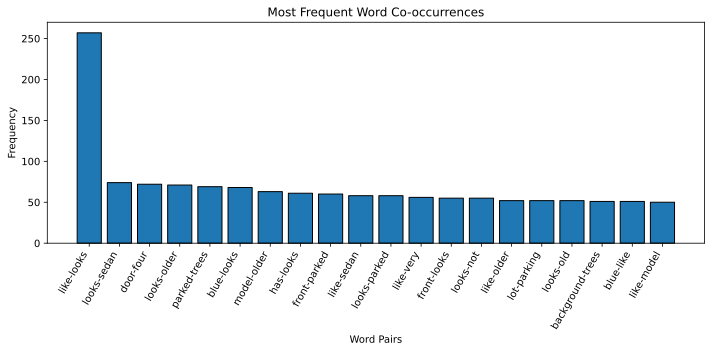

In [483]:
plot_bargraph(
    df=co_pair_df,
    x_col="word",
    y_col="count",
    top_n=20,
    xlabel="Word Pairs",
    ylabel="Frequency",
    title="Most Frequent Word Co-occurrences"
)

## 3. LDA Topic Modeling

Latent Dirichlet Allocation (LDA) will be used to identify the semantic clusters in participants’ free responses.

Once LDA suggests groups of words that tend to appear in similar response contexts, each group will be named into topics (e.g., group A: "90s, 80s, old...etc" could be named "era").

In [486]:
# function that runs LDA

def run_lda_topic_modeling(clean_text, n_topics, n_top_words=15):
   
    # clean_text: entire text column that is cleaned
    # n_topics: number of topics LDA to extract from the text
    # n_top_words: number of top representative words to display for each topic
    
    # use WordCloud's stopwords
    stopwords = list(STOPWORDS)
    
    # WordCloud's stopwords include words such as: don't, shouldn't, we'll
    # but when CountVectorizer tokenizes words, words turn into: e.g., don shouldn

    # add tokenized contraction pieces
    stopwords.extend([
        "aren", "couldn", "didn", "doesn", "don",
        "hadn", "hasn", "haven", "isn", "let",
        "ll", "mustn", "re", "shan", "shouldn",
        "ve", "wasn", "weren", "won", "wouldn"
    ])

    # add subject-specific neutral words to the stopwords list
    stopwords.extend(neutral_word_list)
    
    # vectorize text
    vectorizer = CountVectorizer(
        stop_words=stopwords,
        max_df=0.95,
        min_df=5,
        ngram_range=(1, 2)
    )

    X = vectorizer.fit_transform(clean_text)

    # fit LDA
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=0,
        learning_method="batch"
    )

    lda.fit(X)

    # get feature names
    # feature: all representative words included in the document-term matrix
    feature_names = vectorizer.get_feature_names_out()

    # save topic words
    topic_rows = []

    for topic_idx, topic in enumerate(lda.components_):

        top_indices = topic.argsort()[:-n_top_words-1:-1]

        top_words = [feature_names[i] for i in top_indices]

        topic_rows.append({
            "topic_number": topic_idx + 1,
            "top_words": ", ".join(top_words)
        })

    # make into a dataframe
    topics_df = pd.DataFrame(topic_rows)

    return topics_df

The function above can be run by copy-pasting the followingcode cell.

In [487]:
# to use the function above
# Here, as an example, LDA extracts 6 topics from responses.

n_topics = 6

topics_df = run_lda_topic_modeling(
    clean_text = clean_data["responses"],
    n_topics = n_topics
)

# check
topics_df

,topic_number,top_words
0,1,"looks, looking, old, sporty, kind, older, seda..."
1,2,"door, two, background, vehicle, sports, road, ..."
2,3,"parked, lot, trees, older, model, looks, parki..."
3,4,"looks, color, blue, nice, vehicle, sedan, fron..."
4,5,"good, old, color, model, probably, design, thi..."
5,6,"door, four, four door, sedan, door sedan, plat..."


In [488]:
# save the output as CSV

topics_df.to_csv(f"data/LDA_{n_topics}_topics.csv", index=False)

Topic modeling has to be tried out multiple times with different numbers of topics. 

For the example dataset, "n_topics= 4 ~ 8" worked. 

In [489]:
# 4 topics

n_topics = 4

topics_df = run_lda_topic_modeling(
    clean_text = clean_data["responses"],
    n_topics = n_topics
)

# check
topics_df

,topic_number,top_words
0,1,"looks, old, looking, probably, sporty, sports,..."
1,2,"good, door, model, plate, four, four door, lic..."
2,3,"parked, trees, sedan, lot, door, looks, older,..."
3,4,"looks, color, blue, vehicle, nice, front, dark..."


In [490]:
# save the output as CSV

topics_df.to_csv(f"data/LDA_{n_topics}_topics.csv", index=False)

In [491]:
# 8 topics

n_topics = 8

topics_df = run_lda_topic_modeling(
    clean_text = clean_data["responses"],
    n_topics = n_topics
)

# check
topics_df

,topic_number,top_words
0,1,"looks, looking, old, sleek, really, european, ..."
1,2,"door, back, vehicle, blue, appears, truck, two..."
2,3,"parked, trees, background, building, front, lo..."
3,4,"looks, color, blue, vehicle, nice, dark, older..."
4,5,"probably, good, old, model, think, color, red,..."
5,6,"good, license, license plate, plate, doesnt, f..."
6,7,"looks, older, model, older model, blue, old, s..."
7,8,"four, four door, door, sedan, black, doors, fo..."


In [493]:
# save the output as CSV

topics_df.to_csv(f"data/LDA_{n_topics}_topics.csv", index=False)

.csv files are saved under /data. These will be inspected to create domain dictionaries in the next step.

## 4. Construct Domain Dictionaries

Following Nicolas et al. (2025), the next step translates the data-driven topics from LDA into interpretable content domains. Nicolas et al. used dictionary-based text analysis to organize open-ended responses into meaningful impression dimensions. 

In the present analysis, the LDA topic-word lists, word frequency results, and repeated topic patterns will be manually reviewed to identify major domains that appeared across participants’ responses.

The domain dictionary consists of sets of manually assigned domain names and their corresponding prototype words. For each domain, prototype words will be selected from participants’ responses; higher frequency words will be prioritized.

In [494]:
# following is a domain dictionary created based on car impression responses
# each domain contains prototypical words selected from participant responses

domain_prototypes = {
    "appearance_style": [
        "sports", "dark", "blue", "black", "red",
        "shiny", "gray", "grey", "white", "small", "black"
    ],

    "evaluation": [
        "nice", "good", "good looking", "strange", "bad",
        "attract", "attractive", "unique", "unusual", "beautiful", "ugly"
    ],

    "age_era": [
        "older", "older model", "old", "used", "90s",
        "60s", "80s", "70s", "newer", "dated", "new"
    ],

    "condition_functionality": [
        "muscle", "condition", "fast", "powerful", "safe",
        "hard", "strong", "clean", "utility", "gas mileage"
    ],

    "context_environment": [
        "parked", "lot", "trees", "building", "parking",
        "parking lot", "background", "grass", "apartments", "lake", "road"
    ]
}

# print domain's names
domain_names = list(domain_prototypes.keys())
domain_names

['appearance_style',
 'evaluation',
 'age_era',
 'condition_functionality',
 'context_environment']

## 5. Semantic Dimension Assignment 

Up to here, the analysis identified possible semantic domains from the LDA results and created a dictionary out of them. 

The next step is to assign participant-generated words to semantic domains. To do this, SBERT (Sentence-BERT) embeddings will be used. SBERT converts words into numerical vector representations that capture semantic meaning. Words with similar meanings are expected to be located closer together in the embedding space.

First, the pretrained SBERT model "sentence-transformers/all-MiniLM-L6-v2" will be loaded.

In [495]:
# load pretrained SBERT model

model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7916.10it/s]


_**Does your output look suspicious?**_

If you run the code cell above and run into a warning that says: "Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads," or see a loading bar ("Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7411.70it/s]"), no need to worry.  

This warning indicates that the pretrained SBERT model (“sentence-transformers/all-MiniLM-L6-v2”) is being downloaded without a Hugging Face authentication token. The model can still be downloaded and loaded successfully without authentication. The authentication is not necessary for research pupose as the model being used is a publicly available pretrained model.

Please proceed.

In the domain dictionary, every semantic domain is represented by a set of prototype words. These prototype words serve as examples of the meaning of each domain. 

Here, the prototype words will be embedded using the SBERT model. Then, the embeddings within each domain will be averaged to create a single centroid vector for that domain.

In [501]:
# create domain centroid vectors

domain_vectors = {}

for domain in domain_names:

    prototype_words = domain_prototypes[domain]

    # embed prototype words
    prototype_embeddings = model.encode(prototype_words)

    # average embeddings
    centroid_vector = prototype_embeddings.mean(axis=0)

    # save centroid
    domain_vectors[domain] = centroid_vector

Next, the cleaned participant responses will be loaded. 

In [514]:
data = pd.read_csv("data/main_clean.csv")

data.head()

,responses
0,a blue car just sitting in an empty parking lo...
1,a white car in a parking lot it might just be ...
2,a gray possibly sitting in a driveway it migh...
3,a blue sedan in a parking lot with trees behin...
4,a red car that is more of an older model that ...


All words appearing in the cleaned responses will be put into a single list. Here, duplicate words will be removed, so that all unique words can be assigned to a semantic domain. (i.e., Word frequency is not considered here.)

The new list of unique words will be called "vocabulary."

In [519]:
# create vocabulary list from participant responses

all_words = []

for text in data["responses"]:

    words = text.split()

    all_words.extend(words)

# remove duplicate words and sort alphabetically
vocabulary = sorted(set(all_words))

print(f"numner of unique words from responses: {len(vocabulary)}")

numner of unique words from responses: 2008


Next, words in the list "vocabulary" will be embedded using the pretrained SBERT model. Embeddings convert each word into a numerical vector representation in a semantic space.

In [524]:
word_embeddings = model.encode(vocabulary)

For each word in "vocabulary," cosine similarity will be calculated between the word embedding and each semantic domain centroid. Each word will then be assigned to the domain with the highest similarity score.

In [525]:
# assign each word to the most semantically similar domain

results = []

for i, word in enumerate(vocabulary):

    word_vector = word_embeddings[i]

    similarity_scores = {}

    # compare with every domain
    for domain in domain_names:

        similarity = cosine_similarity(
            [word_vector],
            [domain_vectors[domain]]
        )[0][0]

        similarity_scores[domain] = similarity

    # highest similarity domain
    best_domain = max(
        similarity_scores,
        key=similarity_scores.get
    )

    best_similarity = similarity_scores[best_domain]

    results.append({
        "word": word,
        "assigned_domain": best_domain,
        "similarity_score": best_similarity
    })

The semantic dimension assignment results will be converted into a dataframe. 

In [529]:
assignment_df = pd.DataFrame(results)

assignment_df.head()

,word,assigned_domain,similarity_score
0,-,evaluation,0.432052
1,007,appearance_style,0.413574
2,00s,age_era,0.388146
3,10,appearance_style,0.523093
4,10000,condition_functionality,0.300814


The semantic dimension assignment results will be sorted by similarity score, so that the words with the strongest semantic association to their assigned domains will be listed first.

In [532]:
assignment_df = assignment_df.sort_values(
    by="similarity_score",
    ascending=False
)

assignment_df.head(30)

,word,assigned_domain,similarity_score
216,black,appearance_style,0.879075
389,color,appearance_style,0.872582
794,grey,appearance_style,0.871799
782,gray,appearance_style,0.865208
390,colored,appearance_style,0.848094
1954,white,appearance_style,0.841580
1200,old,age_era,0.826850
228,blue,appearance_style,0.826477
795,grey-black,appearance_style,0.820542
1203,older,age_era,0.800985


The sorted semantic dimension assignment results will be saved as a .csv file.

In [536]:
assignment_df.to_csv("data/05_semantic_dimension_assignment.csv", index=False)
print("saved!!!!!!!")

saved!!!!!!!


## 6. Calculate Domain Prevalence

The next step will examine the prevalence of semantic domains across participant responses. Using the SBERT-based semantic assignment results from the previous step, each response word will be matched with its assigned semantic domain.

Here, domain prevalence will be operationalized as the proportion of response words assigned to each semantic domain.

But first, the semantic dimension assignment results will be loaded.

In [541]:
assignment_df = pd.read_csv("data/05_semantic_dimension_assignment.csv")

assignment_df.head()

,word,assigned_domain,similarity_score
0,black,appearance_style,0.879075
1,color,appearance_style,0.872582
2,grey,appearance_style,0.871799
3,gray,appearance_style,0.865208
4,colored,appearance_style,0.848094


Next, a dictionary will be created to map each word to its assigned semantic domain. This will make it possible to look up the semantic domain of each word in the participant responses.

In [542]:
# word-to-domain dictionary

word_to_domain = dict(
    zip(
        assignment_df["word"],
        assignment_df["assigned_domain"]
    )
)

Each word across participant responses will be matched with its assigned semantic domain.

In [548]:
all_assigned_domains = []

for word in all_words:

    if word in word_to_domain:

        assigned_domain = word_to_domain[word]

        all_assigned_domains.append(assigned_domain)

The number of words assigned to each semantic domain will be counted. This will show how frequently each semantic domain appears across all participant responses.

In [549]:
domain_counts = Counter(all_assigned_domains)

domain_counts

Counter({'evaluation': 8348,
         'condition_functionality': 7639,
         'context_environment': 4112,
         'appearance_style': 1923,
         'age_era': 833})

The domain counts will be converted into a dataframe for convenience in viewing and saving.

In [551]:
prevalence_df = pd.DataFrame(
    domain_counts.items(),
    columns=["domain", "count"]
)

prevalence_df = prevalence_df.sort_values(
    "count",
    ascending=False
).reset_index(drop=True)

# check
prevalence_df

,domain,count
0,evaluation,8348
1,condition_functionality,7639
2,context_environment,4112
3,appearance_style,1923
4,age_era,833


The proportion and percentage of response words assigned to each semantic domain will be calculated.

In [553]:
#proportion
prevalence_df["proportion"] = (
    prevalence_df["count"]
    / prevalence_df["count"].sum()
)

# percentage
prevalence_df["percentage"] = (
    prevalence_df["proportion"] * 100
)

# check; dataframe is updated
prevalence_df

,domain,count,proportion,percentage
0,evaluation,8348,0.365259,36.525924
1,condition_functionality,7639,0.334238,33.423758
2,context_environment,4112,0.179917,17.991687
3,appearance_style,1923,0.084139,8.413914
4,age_era,833,0.036447,3.644717


The dataframe above will be saved as a .csv file.

In [555]:
prevalence_df.to_csv("data/06_domain_prevalence.csv", index=False)
print("saved!!")

saved!!


### Data Visualiation

A bar graph function can be used again to visualize how frequently each semantic domain appears across participants' responses.

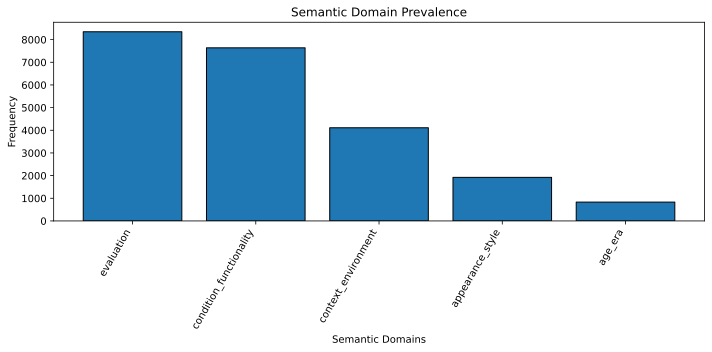

In [556]:
plot_bargraph(
    df=prevalence_df,
    x_col="domain",
    y_col="count",
    top_n=5,
    xlabel="Semantic Domains",
    ylabel="Frequency",
    title="Semantic Domain Prevalence"
)

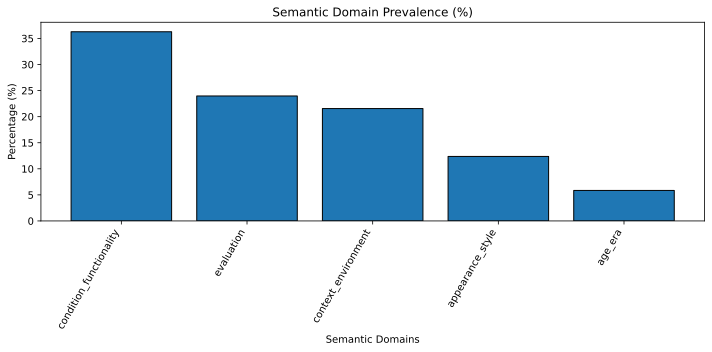

In [359]:
plot_bargraph(
    df=prevalence_df,
    x_col="domain",
    y_col="percentage",
    top_n=5,
    xlabel="Semantic Domains",
    ylabel="Percentage (%)",
    title="Semantic Domain Prevalence (%)"
)

A pie chart can also be drafted to show the proportional distribution of domain prevalence.

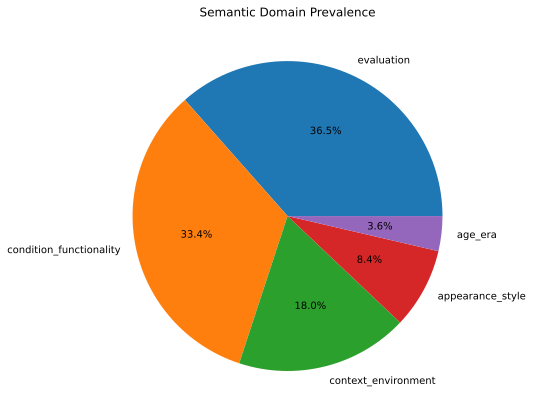

In [558]:
# pie chart

plt.figure(figsize=(7, 7))

plt.pie(
    prevalence_df["percentage"],
    labels=prevalence_df["domain"],

    autopct="%1.1f%%"
)

plt.title("Semantic Domain Prevalence")




plt.show()